In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree

In [9]:
df = pd.read_csv("dados.csv")

In [10]:
df.fillna(0, inplace=True)
features = df.copy()
features.drop(columns={"id_empresa", "maturidade"} , axis=1, inplace=True)
target = df[["maturidade"]]


In [11]:
arvore = tree.DecisionTreeClassifier(max_depth=10, min_samples_leaf=4)
arvore.fit(features, target)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=4)

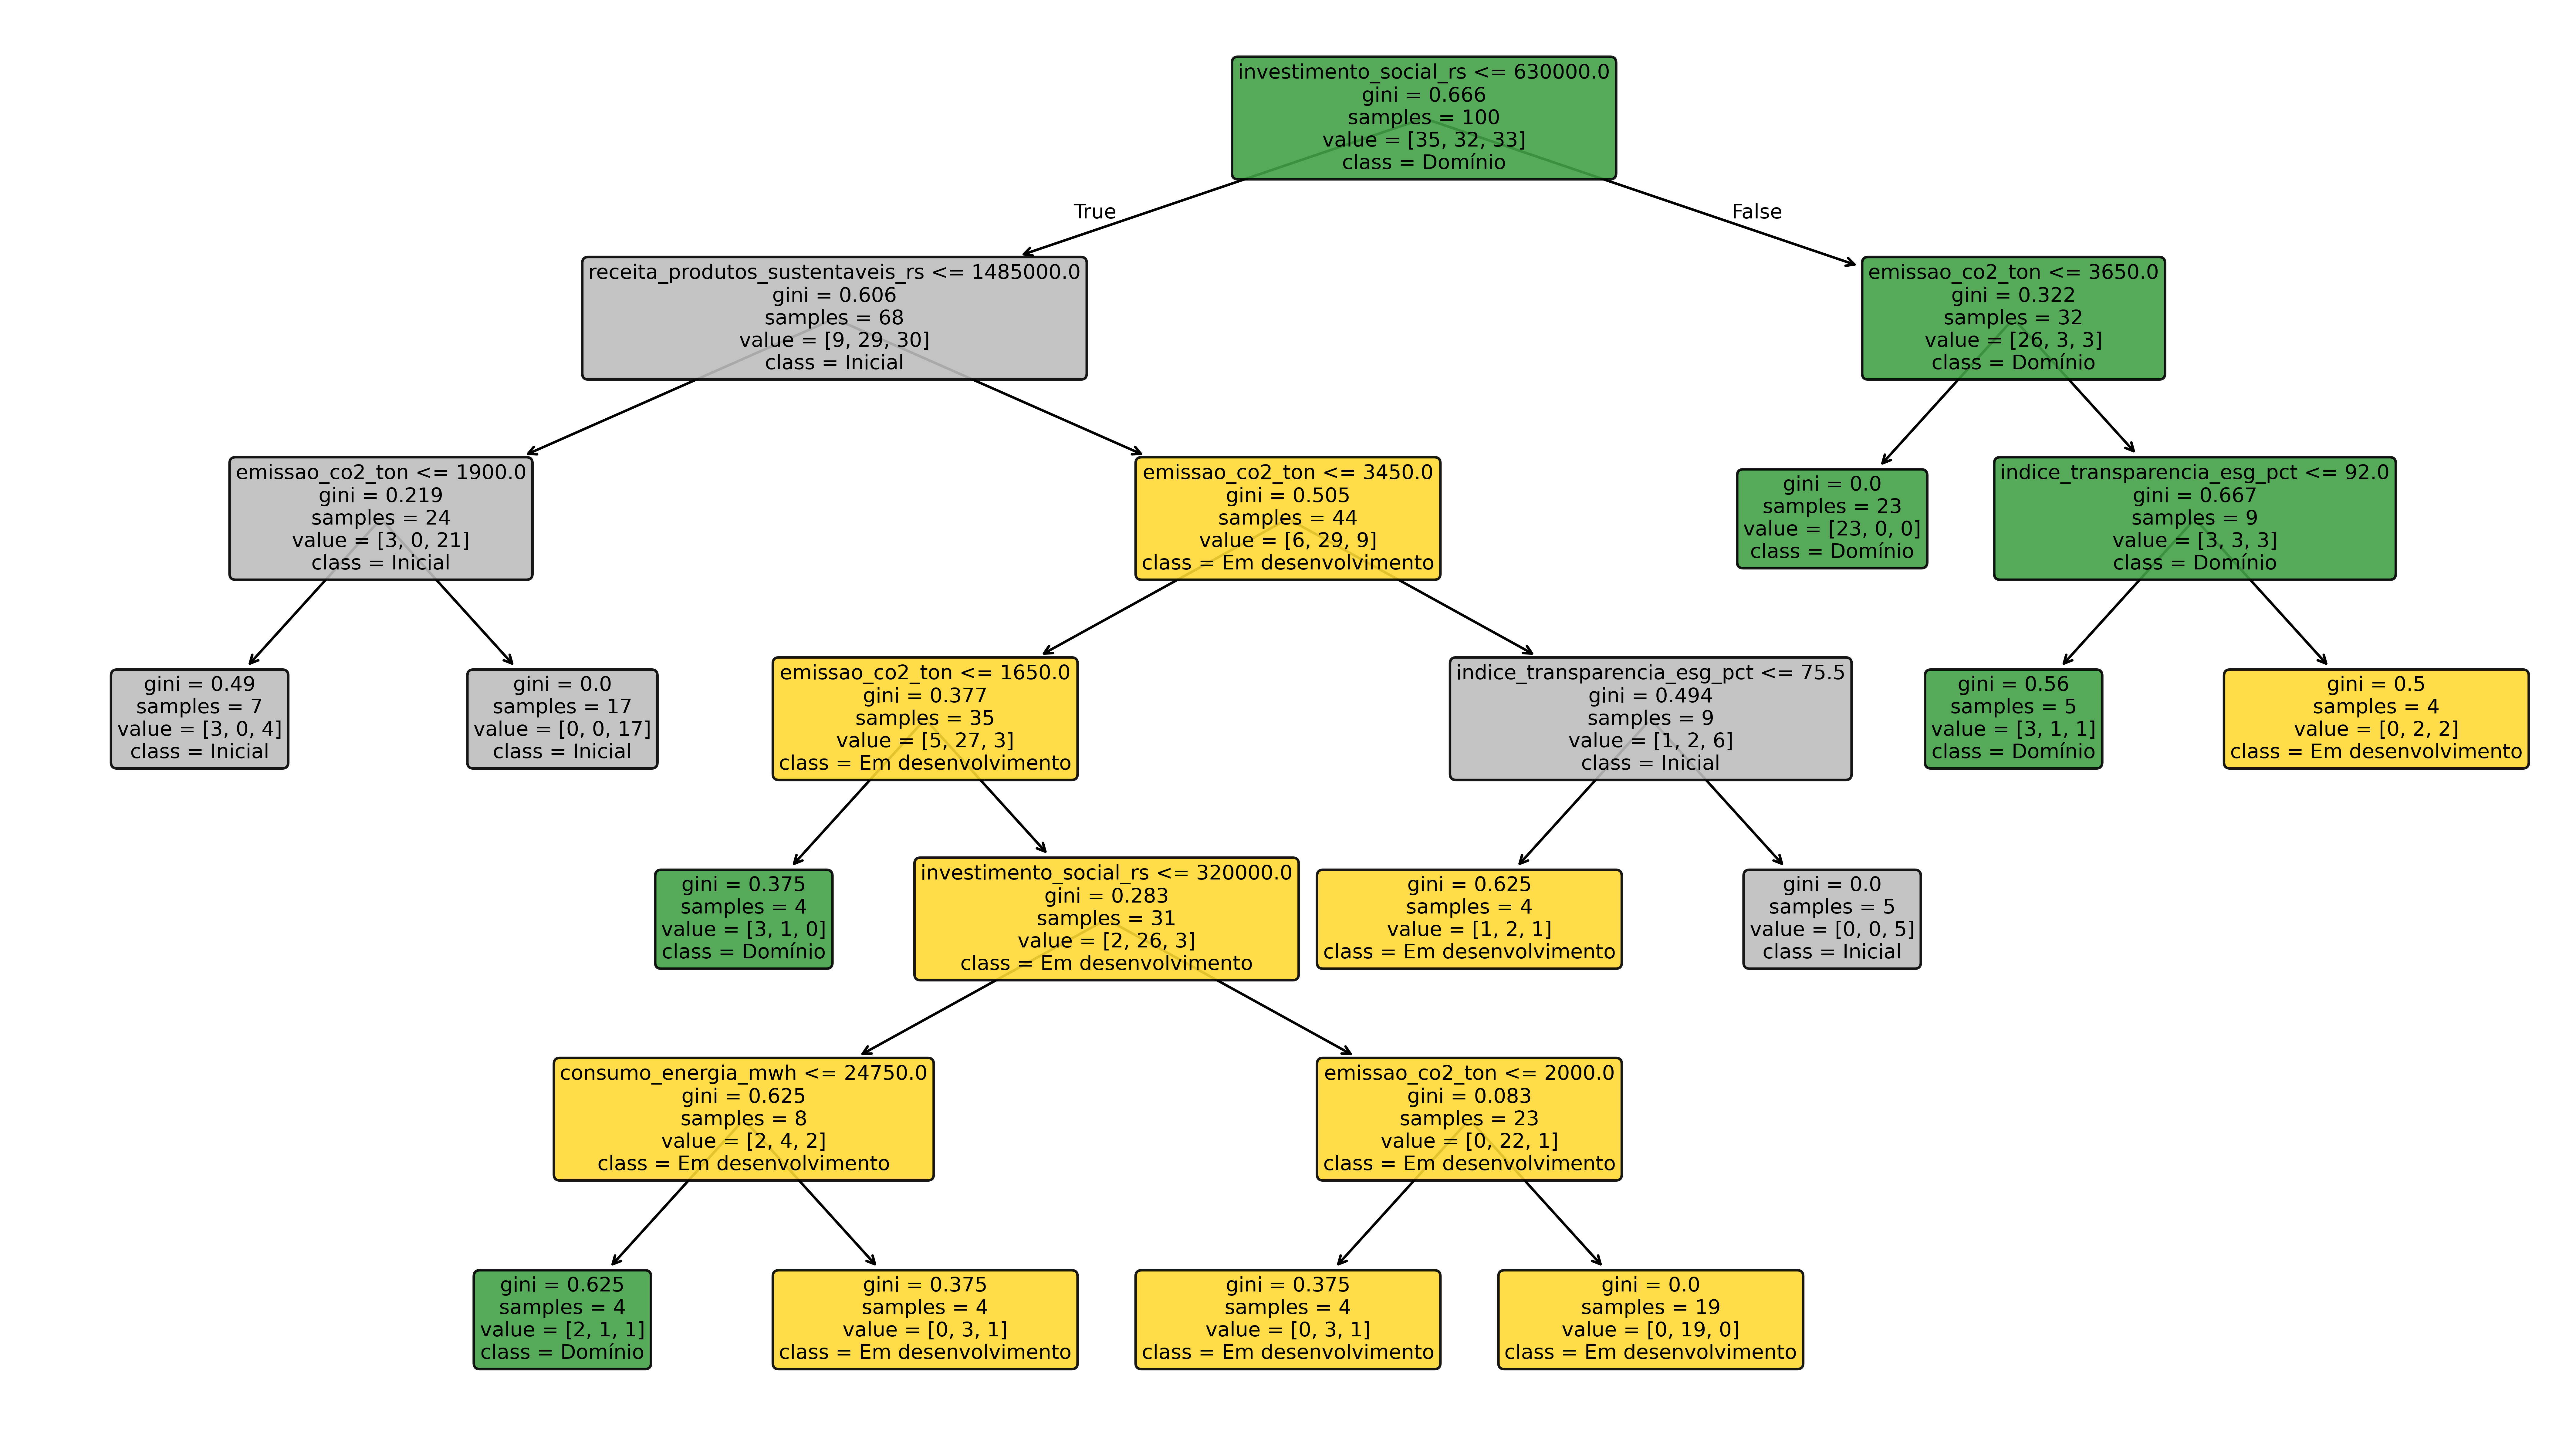

In [12]:

cores = {
    'Inicial': '#BDBDBD',              # cinza
    'Em desenvolvimento': '#FDD835',  # amarelo
    'Domínio': '#43A047'              # verde
}

fig, ax = plt.subplots(figsize=(18,10), dpi=600)

arvore_plot = tree.plot_tree(
    arvore,
    class_names=arvore.classes_,
    feature_names=features.columns,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)

# Ajusta manualmente as cores dos nós
for i, no in enumerate(arvore_plot):

    texto = no.get_text()

    # Identifica a classe do nó
    for classe, cor in cores.items():
        if f"class = {classe}" in texto:

            # altera cor do box
            no.get_bbox_patch().set_facecolor(cor)

            # cor da borda
            no.get_bbox_patch().set_edgecolor("black")

            # transparência
            no.get_bbox_patch().set_alpha(0.9)

plt.show()

In [ ]:
arvore.feature_importances_

var_importancia = pd.DataFrame(
    {
        'variaveis': features.columns,
        'importancia': arvore.feature_importances_
    }
).sort_values(by='importancia', ascending=False)
# %%
var_importancia

,variaveis,importancia
2,investimento_social_rs,0.346948
0,emissao_co2_ton,0.287486
3,receita_produtos_sustentaveis_rs,0.280798
9,indice_transparencia_esg_pct,0.064315
1,consumo_energia_mwh,0.020453
4,diversidade_lideranca_pct,0.000000
5,reciclagem_residuos_pct,0.000000
6,uso_energia_renovavel_pct,0.000000
7,engajamento_colaboradores_esg_pct,0.000000
8,compliance_fornecedores_pct,0.000000


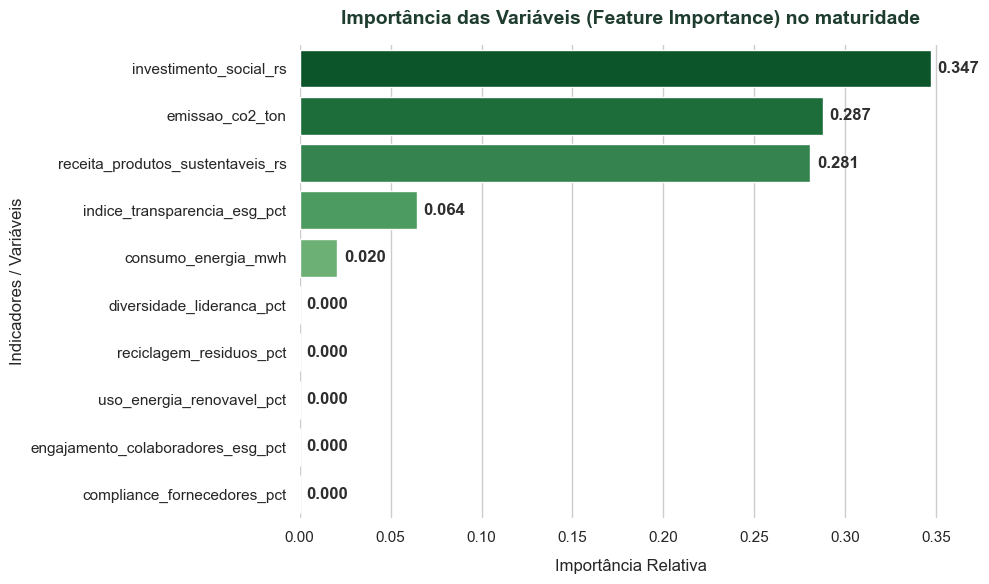

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='importancia', 
    y='variaveis', 
    data=var_importancia, 
    palette='Greens_r',
    hue='variaveis', # Garante a aplicação correta da paleta por categoria
    legend=False
)

plt.title('Importância das Variáveis (Feature Importance) no maturidade', fontsize=14, pad=15, weight='bold', color='#1e3d2f')
plt.xlabel('Importância Relativa', fontsize=12, labelpad=10)
plt.ylabel('Indicadores / Variáveis', fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=5, color='#2e2e2e', weight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()